# Modality topologies

scIToFlow's latent cascade is not hardcoded. It is defined over a configurable set of
states ({mod}`scitoflow.core.topology`), so the same model runs on the full
chromatin/unspliced/spliced cascade or on any reduction. This notebook enumerates the
presets, shows how the encoders, decoders, and parameter counts change, and confirms each
one runs a forward pass on CPU.

In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)
torch.manual_seed(0)
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

## The presets

{func}`scitoflow.get_topology` resolves a preset name to a `Topology`: an ordered chain of
latent states, the subset that is decoded back to gene space, and the AnnData layer each
state reads.

In [2]:
from scitoflow import get_topology
from scitoflow.core.topology import PRESETS

rows = []
for name in PRESETS:
    topo = get_topology(name)
    rows.append({
        "topology": name,
        "cascade": " -> ".join(topo.states) + " -> r",
        "decoded": ", ".join(topo.decoded),
        "layers": ", ".join(topo.layer[s] for s in topo.states),
        "production edge": " -> ".join(topo.production_edge),
    })
pd.DataFrame(rows).set_index("topology")

/home/bernaljp/micromamba/envs/scitoflow/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,cascade,decoded,layers,production edge
topology,,,,
full,c -> u -> s -> r,"u, s","M_c, M_u, M_s",u -> s
no_unspliced,c -> s -> r,s,"M_c, M_s",c -> s
rna_only,u -> s -> r,"u, s","M_u, M_s",u -> s
minimal,s -> r,s,M_s,r -> s
labeling,c -> nascent -> total -> r,"nascent, total","M_c, M_n, M_t",nascent -> total


- **full** `c -> u -> s -> r`: the default, for co-profiled chromatin + unspliced + spliced.
- **no_unspliced** `c -> s -> r`: when only chromatin and spliced are available.
- **rna_only** `u -> s -> r` and **minimal** `s -> r`: no chromatin channel.
- **labeling** `c -> nascent -> total -> r`: metabolic-labeling data (nascent/total instead
  of intron-based unspliced/spliced).

The **production edge** is the last cascade edge, where the biophysical positive-rate
regularizer applies (splicing in `full`, chromatin -> spliced in `no_unspliced`).

## Parameter counts across topologies

Building the same-sized model on each topology, the encoders and decoders scale with the
number of states and decoded modalities. The built-in example dataset carries every layer a
preset might need (`M_c`, `M_u`, `M_s`, `M_n`, `M_t`), so all five presets are directly
runnable on it.

In [3]:
from scitoflow import VAE, simulate_dataset

adata = simulate_dataset(n_genes=50, grid=14, seed=0)

def build(topology):
    return VAE(observed=adata.n_vars, latent_dim=8, zr_dim=2, h_dim=2,
               encoder_hidden=16, decoder_hidden=16, t_encoder_hidden=16, graph_hidden=16,
               velocity_model_hidden=16, num_steps=20, ode_grid=20,
               topology=topology, use_spatial=True, use_feedback=True,
               use_grid_ode=True, use_expr_gnn=False)

counts = []
models = {}
for name in PRESETS:
    m = build(name)
    models[name] = m
    counts.append({"topology": name,
                   "states": m.topo.n_states,
                   "decoded": len(m.topo.decoded),
                   "parameters": sum(p.numel() for p in m.parameters())})
counts = pd.DataFrame(counts).set_index("topology")
counts

,states,decoded,parameters
topology,,,
full,3,2,10245
no_unspliced,2,1,6787
rna_only,2,2,8053
minimal,1,1,4595
labeling,3,2,10245


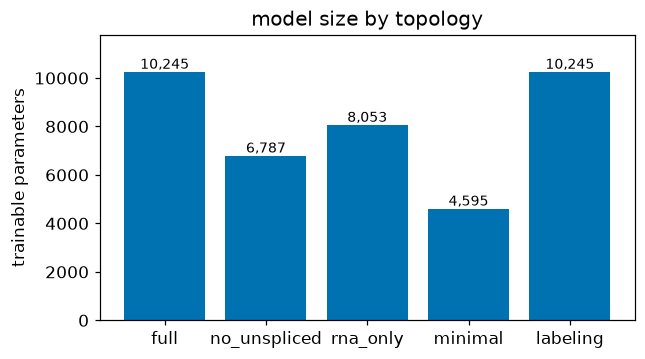

In [4]:
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.bar(counts.index, counts["parameters"], color="#0072B2")
ax.set_ylabel("trainable parameters"); ax.set_title("model size by topology")
for i, v in enumerate(counts["parameters"]):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
ax.margins(y=0.15)
fig.tight_layout()

## Every topology runs a forward pass

We encode the example data through each model's `latent_embedding`. The latent state has
`n_states * latent_dim` cascade dimensions plus the niche factor `h`.

In [5]:
from sklearn.neighbors import kneighbors_graph

coords = np.c_[adata.obs["x_position"], adata.obs["y_position"]]
A = kneighbors_graph(coords, 8, mode="connectivity").tocoo()
edge_spatial = torch.tensor(np.vstack([A.row, A.col]), dtype=torch.long)

out_rows = []
for name, m in models.items():
    m.eval()
    data = {st: torch.tensor(adata.layers[m.topo.layer[st]].toarray(), dtype=torch.float64)
            for st in m.topo.states}
    with torch.no_grad():
        latent_state, *_ , = m.latent_embedding(data, edge_index_spatial=edge_spatial)
    out_rows.append({"topology": name,
                     "cascade latent dim": m.topo.n_states * m.latent,
                     "latent_state shape": tuple(latent_state.shape)})
pd.DataFrame(out_rows).set_index("topology")

,cascade latent dim,latent_state shape
topology,,
full,24,"(196, 28)"
no_unspliced,16,"(196, 20)"
rna_only,16,"(196, 20)"
minimal,8,"(196, 12)"
labeling,24,"(196, 28)"


## Ablation flags

Independently of the topology, four boolean flags toggle model components. They define the
ablations reported in the paper and are useful for testing what a dataset actually needs:

| Flag | Default | Off means |
|------|---------|-----------|
| `use_spatial` | `True` | zero the spatial GraphSAGE factor (the niche ablation / counterfactual) |
| `use_feedback` | `True` | open the regulatory loop (`r` no longer drives chromatin) |
| `use_expr_gnn` | `False` | the expression conditioner is an MLP instead of a second GNN |
| `use_grid_ode` | `True` | integrate per cell (legacy, quadratic) instead of on the shared grid |

See {doc}`03_training_and_readouts` for the niche counterfactual in action.